# ICCO world cocoa balance sheet — a readable EDA

**One row per cocoa year. Fifteen rows total. No producer, ingestion job, Gold dataset, or live query is needed to read or rerun this notebook.**

This notebook embeds an exact 7.5 KB Parquet replica of the current canonical `silver_icco_cocoa` object. Start with the dashboard, inspect the complete DataFrame, then follow the five charts. Technical provenance and feature constraints are kept at the end.

In [1]:
_PAYLOAD_B64 = "eNqljlsOwiAQRbdi+NYUpKB0K8Y0I8woidAKxURN9y4+Ehfg78nNPefBKEHAviTPugXDcEDn0K1GSJeCU9c0+QRrpRvOqVXWABKhVqTIaVKIJKXmoM32IMVGGGOElNSaykhap7UAw4VouWHLBQsQPWGevrZYzudKxzRcMUK0WNmDWQgj+GPsvfttKA13jP2n9VP0yv07aq7fuYQA6faWE8JUEvYWovMOJswV7/bz/AQfu1uE"
_FRAME_B64 = "UEFSMRUEFcoCFeoBTBUeFQASAAClASgHAAAAMjAwNy8wOAkLEDExLzEyDQsMMi8xMw0LDDMvMTQNCww0LzE1DQsMNS8xNg0LDDYvMTcNCwg3LzERTQw4LzE5DRYMOS8yMAkLEDIwLzIxDQsIMS8yDW4MMjIvMg1uPDIzLzI0BwAAADIwMjQvMjUVABUUFRgsFR4VEBUGFQYcNgAoBzIwMjQvMjUYBzIwMDcvMDgREQAAAAokBAUQMlR2mLrcDhUEFaQDFfQBTBUeFQASAADSATQKAAAAMjAwOC0wMi0yOAkOHDEyLTExLTMwDQ4AMwEOBDI5DQ4ANAUOESoMNS0wNRkcGDYtMDUtMzENKgw3LTA4GQ4AODIOAAA5BQ4NYhwyMC0xMi0wMgk4BDIxBRwNRgQyMy5UAAAyBYwVOAV+FQ4YNi0wNS0yORUAFSAVJCwVHhUQFQYVBhw2ACgKMjAyNi0wNS0yORgKMjAwOC0wMi0yOBERAAAAEDwCAAAAHgEEBRAyVHaYutwOFQQV8AEVngFMFR4VABIAAHgAAAEBCAKtQAEHCACorwkIBLauCQgEDbEJCARIsAkIAI4NIARcsgkQACUNCADxDQgAWQ0IBBW0CSAEdLMJCABZDQgoELFAAAAAAABzskAVABUgFSQsFR4VEBUGFQYcGAgAAAAAABW0QBgIAAAAAAACrUAWACgIAAAAAAAVtEAYCAAAAAAAAq1AEREAAAAQPAIAAAAeAQQFEDJUdpi63A4VBBXwARWeAUwVHhUAEgAAeAAAAQEIHq1AAQcIAKKuCQgEqK8JCASssAkIBESwCQgAUw0IALoNCATYsQkYBK+yCQgAFw0IAPwNCATQswkYAIoNCCjSskAAAAAAABSyQBUAFSAVJCwVHhUQFQYVBhwYCAAAAAAA0LNAGAgAAAAAAB6tQBYAKAgAAAAAANCzQBgIAAAAAAAerUAREQAAABA8AgAAAB4BBAUQMlR2mLrcDhUEFfABFZYBTBUeFQASAAB4AAAFAQSYQAUHBCCdDQgAmgkIBOyZCQgAiA0gBGCWCRAE1JsJCAB0DQgAMA0IADQNCASsngkgAIANQABADRgo2JNAAAAAAACglEAVABUgFSQsFR4VEBUGFQYcGAgAAAAAAKyeQBgIAAAAAADYk0AWACgIAAAAAACsnkAYCAAAAAAA2JNAEREAAAAQPAIAAAAeAQQFEDJUdpi63A4VBBXwARWeAUwVHhUAEgAAeAAAAQEIgEnAAQcMAIBWQAUIBABkDRAASg0QADENEABmCQgIMHdACSgAPw0IADINCAAzCQgEwGwNCABhCTAEwFgJCCjgfsAAAAAAAABIQBUAFSAVJCwVHhUQFQYVBhwYCAAAAAAAMHdAGAgAAAAAAOB+wBYAKAgAAAAAADB3QBgIAAAAAADgfsAREQAAABA8AgAAAB4BBAUQMlR2mLrcDhUEFfABFfYBTBUeFQASAAB48HfHtjXuTGDaP383TrLFbN4/ltk3t59o2j+snNnfkeDYP3yXGNxxIdg/z87wJzzu1T9LEpPajJ7aP8eM8nnQndg/6QDBNk9I1z9g98Nxeg/YPwy6sxWn2dk/BJepxtKX1D8vvqZHdFDWPxrI3fG83tA//YLwDQ1B0j8VABUgFSQsFR4VEBUGFQYcGAh/N06yxWzePxgIGsjd8bze0D8WACgIfzdOssVs3j8YCBrI3fG83tA/EREAAAAQPAIAAAAeAQQFEDJUdpi63A4VBBXgARWmAUwVHBUAEgAAcAAAAQEI4K1AAQcwAHiuQKuqqqqq4K9AVQEBBEGwCRAEa7AJEAhwsEAFKAD3DRAEwLEJIAQ0sgkYBJayCSgA9g0QBHKzCRgoZLNAAAAAAADQskAVABUiFSYsFR4VEBUGFQYcGAgAAAAAAHKzQBgIAAAAAADgrUAWAigIAAAAAABys0AYCAAAAAAA4K1AEREAAAARQAMAAAAF/n8EBRAyVHaYutwAFQQV4AEVvAFMFRwVABIAAHAAAAEBCEBYQAEHiAAAY0BQVVVVVXVnQABYVVVVVQVAAKuqqqqqOMDAqqqqqmpSCSgkIGxAYFVVVVXVbQ0gBD3ABUAEgFkJGAQ1awkoBAA4CQgoQGLAAAAAAACAZ8AVABUiFSYsFR4VEBUGFQYcGAhgVVVVVdVtQBgIAAAAAACAZ8AWAigIYFVVVVXVbUAYCAAAAAAAgGfAEREAAAARQAMAAAAF/n8EBRAyVHaYutwAFQQVGhUeTBUCFQASAAANMAkAAABpY2NvX3FiY3MVABUSFRYsFR4VEBUGFQYcNgAoCWljY29fcWJjcxgJaWNjb19xYmNzEREAAAAJIAIAAAAeAQEeABUEGbw1ABgGc2NoZW1hFRQAFQwlABgKY29jb2FfeWVhciUATBwAAAAVDCUCGBNsYXRlc3RfcmVsZWFzZV9kYXRlJQBMHAAAABUKJQIYDXByb2R1Y3Rpb25fa3QAFQolAhgMZ3JpbmRpbmdzX2t0ABUKJQIYDWVuZF9zdG9ja3Nfa3QAFQolAhgSc3VycGx1c19kZWZpY2l0X2t0ABUKJQIYCHN1X3JhdGlvABUKJQIYE2dyaW5kaW5nc18zeXJfdHJlbmQAFQolAhgTZ3JpbmRpbmdzX3RyZW5kX2RldgAVDCUCGAZzb3VyY2UlAEwcAAAAFh4ZHBmsJgAcFQwZNQAGEBkYCmNvY29hX3llYXIVAhYeFtADFvQCJpICJggcNgAoBzIwMjQvMjUYBzIwMDcvMDgREQAZLBUEFQAVAgAVABUQFQIAPBbSARkGGQYAAAAmABwVDBk1AAYQGRgTbGF0ZXN0X3JlbGVhc2VfZGF0ZRUCFh4WwgQWlgMmkAUm/AIcNgAoCjIwMjYtMDUtMjkYCjIwMDgtMDItMjgREQAZLBUEFQAVAgAVABUQFQIAPBasAhkGGSYAHgAAACYAHBUKGTUABhAZGA1wcm9kdWN0aW9uX2t0FQIWHhauAxbgAibQByaSBhwYCAAAAAAAFbRAGAgAAAAAAAKtQBYAKAgAAAAAABW0QBgIAAAAAAACrUAREQAZLBUEFQAVAgAVABUQFQIAPCkGGSYAHgAAACYAHBUKGTUABhAZGAxncmluZGluZ3Nfa3QVAhYeFq4DFuACJrAKJvIIHBgIAAAAAADQs0AYCAAAAAAAHq1AFgAoCAAAAAAA0LNAGAgAAAAAAB6tQBERABksFQQVABUCABUAFRAVAgA8KQYZJgAeAAAAJgAcFQoZNQAGEBkYDWVuZF9zdG9ja3Nfa3QVAhYeFq4DFtgCJogNJtILHBgIAAAAAACsnkAYCAAAAAAA2JNAFgAoCAAAAAAArJ5AGAgAAAAAANiTQBERABksFQQVABUCABUAFRAVAgA8KQYZJgAeAAAAJgAcFQoZNQAGEBkYEnN1cnBsdXNfZGVmaWNpdF9rdBUCFh4WrgMW4AIm6A8mqg4cGAgAAAAAADB3QBgIAAAAAADgfsAWACgIAAAAAAAwd0AYCAAAAAAA4H7AEREAGSwVBBUAFQIAFQAVEBUCADwpBhkmAB4AAAAmABwVChk1AAYQGRgIc3VfcmF0aW8VAhYeFq4DFrgDJqATJooRHBgIfzdOssVs3j8YCBrI3fG83tA/FgAoCH83TrLFbN4/GAgayN3xvN7QPxERABksFQQVABUCABUAFRAVAgA8KQYZJgAeAAAAJgAcFQoZNQAGEBkYE2dyaW5kaW5nc18zeXJfdHJlbmQVAhYeFqADFuoCJogWJsIUHBgIAAAAAABys0AYCAAAAAAA4K1AFgIoCAAAAAAAcrNAGAgAAAAAAOCtQBERABksFQQVABUCABUAFRAVAgA8KQYZJgIcAAAAJgAcFQoZNQAGEBkYE2dyaW5kaW5nc190cmVuZF9kZXYVAhYeFqADFoADJogZJqwXHBgIYFVVVVXVbUAYCAAAAAAAgGfAFgIoCGBVVVVV1W1AGAgAAAAAAIBnwBERABksFQQVABUCABUAFRAVAgA8KQYZJgIcAAAAJgAcFQwZNQAGEBkYBnNvdXJjZRUCFh4WogEWqgEm5homrBocNgAoCWljY29fcWJjcxgJaWNjb19xYmNzEREAGSwVBBUAFQIAFQAVEBUCADwWjgIZBhkmAB4AAAAW2iAWHiYIFs4bABksGAZwYW5kYXMYlQt7ImluZGV4X2NvbHVtbnMiOiBbXSwgImNvbHVtbl9pbmRleGVzIjogW10sICJjb2x1bW5zIjogW3sibmFtZSI6ICJjb2NvYV95ZWFyIiwgImZpZWxkX25hbWUiOiAiY29jb2FfeWVhciIsICJwYW5kYXNfdHlwZSI6ICJ1bmljb2RlIiwgIm51bXB5X3R5cGUiOiAic3RyIiwgIm1ldGFkYXRhIjogbnVsbH0sIHsibmFtZSI6ICJsYXRlc3RfcmVsZWFzZV9kYXRlIiwgImZpZWxkX25hbWUiOiAibGF0ZXN0X3JlbGVhc2VfZGF0ZSIsICJwYW5kYXNfdHlwZSI6ICJ1bmljb2RlIiwgIm51bXB5X3R5cGUiOiAic3RyIiwgIm1ldGFkYXRhIjogbnVsbH0sIHsibmFtZSI6ICJwcm9kdWN0aW9uX2t0IiwgImZpZWxkX25hbWUiOiAicHJvZHVjdGlvbl9rdCIsICJwYW5kYXNfdHlwZSI6ICJmbG9hdDY0IiwgIm51bXB5X3R5cGUiOiAiZmxvYXQ2NCIsICJtZXRhZGF0YSI6IG51bGx9LCB7Im5hbWUiOiAiZ3JpbmRpbmdzX2t0IiwgImZpZWxkX25hbWUiOiAiZ3JpbmRpbmdzX2t0IiwgInBhbmRhc190eXBlIjogImZsb2F0NjQiLCAibnVtcHlfdHlwZSI6ICJmbG9hdDY0IiwgIm1ldGFkYXRhIjogbnVsbH0sIHsibmFtZSI6ICJlbmRfc3RvY2tzX2t0IiwgImZpZWxkX25hbWUiOiAiZW5kX3N0b2Nrc19rdCIsICJwYW5kYXNfdHlwZSI6ICJmbG9hdDY0IiwgIm51bXB5X3R5cGUiOiAiZmxvYXQ2NCIsICJtZXRhZGF0YSI6IG51bGx9LCB7Im5hbWUiOiAic3VycGx1c19kZWZpY2l0X2t0IiwgImZpZWxkX25hbWUiOiAic3VycGx1c19kZWZpY2l0X2t0IiwgInBhbmRhc190eXBlIjogImZsb2F0NjQiLCAibnVtcHlfdHlwZSI6ICJmbG9hdDY0IiwgIm1ldGFkYXRhIjogbnVsbH0sIHsibmFtZSI6ICJzdV9yYXRpbyIsICJmaWVsZF9uYW1lIjogInN1X3JhdGlvIiwgInBhbmRhc190eXBlIjogImZsb2F0NjQiLCAibnVtcHlfdHlwZSI6ICJmbG9hdDY0IiwgIm1ldGFkYXRhIjogbnVsbH0sIHsibmFtZSI6ICJncmluZGluZ3NfM3lyX3RyZW5kIiwgImZpZWxkX25hbWUiOiAiZ3JpbmRpbmdzXzN5cl90cmVuZCIsICJwYW5kYXNfdHlwZSI6ICJmbG9hdDY0IiwgIm51bXB5X3R5cGUiOiAiZmxvYXQ2NCIsICJtZXRhZGF0YSI6IG51bGx9LCB7Im5hbWUiOiAiZ3JpbmRpbmdzX3RyZW5kX2RldiIsICJmaWVsZF9uYW1lIjogImdyaW5kaW5nc190cmVuZF9kZXYiLCAicGFuZGFzX3R5cGUiOiAiZmxvYXQ2NCIsICJudW1weV90eXBlIjogImZsb2F0NjQiLCAibWV0YWRhdGEiOiBudWxsfSwgeyJuYW1lIjogInNvdXJjZSIsICJmaWVsZF9uYW1lIjogInNvdXJjZSIsICJwYW5kYXNfdHlwZSI6ICJ1bmljb2RlIiwgIm51bXB5X3R5cGUiOiAic3RyIiwgIm1ldGFkYXRhIjogbnVsbH1dLCAiYXR0cmlidXRlcyI6IHt9LCAiY3JlYXRvciI6IHsibGlicmFyeSI6ICJweWFycm93IiwgInZlcnNpb24iOiAiMjUuMC4wIn0sICJwYW5kYXNfdmVyc2lvbiI6ICIzLjAuMyJ9ABgMQVJST1c6c2NoZW1hGJgWLy8vLy8wZ0lBQUFRQUFBQUFBQUtBQTRBQmdBRkFBZ0FDZ0FBQUFBQkJBQVFBQUFBQUFBS0FBd0FBQUFFQUFnQUNnQUFBTXdGQUFBRUFBQUFBUUFBQUF3QUFBQUlBQXdBQkFBSUFBZ0FBQUNrQlFBQUJBQUFBSlVGQUFCN0ltbHVaR1Y0WDJOdmJIVnRibk1pT2lCYlhTd2dJbU52YkhWdGJsOXBibVJsZUdWeklqb2dXMTBzSUNKamIyeDFiVzV6SWpvZ1czc2libUZ0WlNJNklDSmpiMk52WVY5NVpXRnlJaXdnSW1acFpXeGtYMjVoYldVaU9pQWlZMjlqYjJGZmVXVmhjaUlzSUNKd1lXNWtZWE5mZEhsd1pTSTZJQ0oxYm1samIyUmxJaXdnSW01MWJYQjVYM1I1Y0dVaU9pQWljM1J5SWl3Z0ltMWxkR0ZrWVhSaElqb2diblZzYkgwc0lIc2libUZ0WlNJNklDSnNZWFJsYzNSZmNtVnNaV0Z6WlY5a1lYUmxJaXdnSW1acFpXeGtYMjVoYldVaU9pQWliR0YwWlhOMFgzSmxiR1ZoYzJWZlpHRjBaU0lzSUNKd1lXNWtZWE5mZEhsd1pTSTZJQ0oxYm1samIyUmxJaXdnSW01MWJYQjVYM1I1Y0dVaU9pQWljM1J5SWl3Z0ltMWxkR0ZrWVhSaElqb2diblZzYkgwc0lIc2libUZ0WlNJNklDSndjbTlrZFdOMGFXOXVYMnQwSWl3Z0ltWnBaV3hrWDI1aGJXVWlPaUFpY0hKdlpIVmpkR2x2Ymw5cmRDSXNJQ0p3WVc1a1lYTmZkSGx3WlNJNklDSm1iRzloZERZMElpd2dJbTUxYlhCNVgzUjVjR1VpT2lBaVpteHZZWFEyTkNJc0lDSnRaWFJoWkdGMFlTSTZJRzUxYkd4OUxDQjdJbTVoYldVaU9pQWlaM0pwYm1ScGJtZHpYMnQwSWl3Z0ltWnBaV3hrWDI1aGJXVWlPaUFpWjNKcGJtUnBibWR6WDJ0MElpd2dJbkJoYm1SaGMxOTBlWEJsSWpvZ0ltWnNiMkYwTmpRaUxDQWliblZ0Y0hsZmRIbHdaU0k2SUNKbWJHOWhkRFkwSWl3Z0ltMWxkR0ZrWVhSaElqb2diblZzYkgwc0lIc2libUZ0WlNJNklDSmxibVJmYzNSdlkydHpYMnQwSWl3Z0ltWnBaV3hrWDI1aGJXVWlPaUFpWlc1a1gzTjBiMk5yYzE5cmRDSXNJQ0p3WVc1a1lYTmZkSGx3WlNJNklDSm1iRzloZERZMElpd2dJbTUxYlhCNVgzUjVjR1VpT2lBaVpteHZZWFEyTkNJc0lDSnRaWFJoWkdGMFlTSTZJRzUxYkd4OUxDQjdJbTVoYldVaU9pQWljM1Z5Y0d4MWMxOWtaV1pwWTJsMFgydDBJaXdnSW1acFpXeGtYMjVoYldVaU9pQWljM1Z5Y0d4MWMxOWtaV1pwWTJsMFgydDBJaXdnSW5CaGJtUmhjMTkwZVhCbElqb2dJbVpzYjJGME5qUWlMQ0FpYm5WdGNIbGZkSGx3WlNJNklDSm1iRzloZERZMElpd2dJbTFsZEdGa1lYUmhJam9nYm5Wc2JIMHNJSHNpYm1GdFpTSTZJQ0p6ZFY5eVlYUnBieUlzSUNKbWFXVnNaRjl1WVcxbElqb2dJbk4xWDNKaGRHbHZJaXdnSW5CaGJtUmhjMTkwZVhCbElqb2dJbVpzYjJGME5qUWlMQ0FpYm5WdGNIbGZkSGx3WlNJNklDSm1iRzloZERZMElpd2dJbTFsZEdGa1lYUmhJam9nYm5Wc2JIMHNJSHNpYm1GdFpTSTZJQ0puY21sdVpHbHVaM05mTTNseVgzUnlaVzVrSWl3Z0ltWnBaV3hrWDI1aGJXVWlPaUFpWjNKcGJtUnBibWR6WHpONWNsOTBjbVZ1WkNJc0lDSndZVzVrWVhOZmRIbHdaU0k2SUNKbWJHOWhkRFkwSWl3Z0ltNTFiWEI1WDNSNWNHVWlPaUFpWm14dllYUTJOQ0lzSUNKdFpYUmhaR0YwWVNJNklHNTFiR3g5TENCN0ltNWhiV1VpT2lBaVozSnBibVJwYm1kelgzUnlaVzVrWDJSbGRpSXNJQ0ptYVdWc1pGOXVZVzFsSWpvZ0ltZHlhVzVrYVc1bmMxOTBjbVZ1WkY5a1pYWWlMQ0FpY0dGdVpHRnpYM1I1Y0dVaU9pQWlabXh2WVhRMk5DSXNJQ0p1ZFcxd2VWOTBlWEJsSWpvZ0ltWnNiMkYwTmpRaUxDQWliV1YwWVdSaGRHRWlPaUJ1ZFd4c2ZTd2dleUp1WVcxbElqb2dJbk52ZFhKalpTSXNJQ0ptYVdWc1pGOXVZVzFsSWpvZ0luTnZkWEpqWlNJc0lDSndZVzVrWVhOZmRIbHdaU0k2SUNKMWJtbGpiMlJsSWl3Z0ltNTFiWEI1WDNSNWNHVWlPaUFpYzNSeUlpd2dJbTFsZEdGa1lYUmhJam9nYm5Wc2JIMWRMQ0FpWVhSMGNtbGlkWFJsY3lJNklIdDlMQ0FpWTNKbFlYUnZjaUk2SUhzaWJHbGljbUZ5ZVNJNklDSndlV0Z5Y205M0lpd2dJblpsY25OcGIyNGlPaUFpTWpVdU1DNHdJbjBzSUNKd1lXNWtZWE5mZG1WeWMybHZiaUk2SUNJekxqQXVNeUo5QUFBQUJnQUFBSEJoYm1SaGN3QUFDZ0FBQUJ3Q0FBRFVBUUFBaUFFQUFGQUJBQUFZQVFBQTNBQUFBS2dBQUFCc0FBQUFNQUFBQUFRQUFBQmcvdi8vQUFBQkJSQUFBQUFZQUFBQUJBQUFBQUFBQUFBR0FBQUFjMjkxY21ObEFBQUkvdi8vaVA3Ly93QUFBUU1RQUFBQUpBQUFBQVFBQUFBQUFBQUFFd0FBQUdkeWFXNWthVzVuYzE5MGNtVnVaRjlrWlhZQXh2Ny8vd0FBQWdEQS92Ly9BQUFCQXhBQUFBQWtBQUFBQkFBQUFBQUFBQUFUQUFBQVozSnBibVJwYm1kelh6TjVjbDkwY21WdVpBRCsvdi8vQUFBQ0FQaisvLzhBQUFFREVBQUFBQndBQUFBRUFBQUFBQUFBQUFnQUFBQnpkVjl5WVhScGJ3QUFBQUF1Ly8vL0FBQUNBQ2ovLy84QUFBRURFQUFBQUNRQUFBQUVBQUFBQUFBQUFCSUFBQUJ6ZFhKd2JIVnpYMlJsWm1samFYUmZhM1FBQUdiLy8vOEFBQUlBWVAvLy93QUFBUU1RQUFBQUlBQUFBQVFBQUFBQUFBQUFEUUFBQUdWdVpGOXpkRzlqYTNOZmEzUUFBQUNhLy8vL0FBQUNBSlQvLy84QUFBRURFQUFBQUNBQUFBQUVBQUFBQUFBQUFBd0FBQUJuY21sdVpHbHVaM05mYTNRQUFBQUF6di8vL3dBQUFnREkvLy8vQUFBQkF4QUFBQUFrQUFBQUJBQUFBQUFBQUFBTkFBQUFjSEp2WkhWamRHbHZibDlyZEFBR0FBZ0FCZ0FHQUFBQUFBQUNBQkFBRkFBSUFBWUFCd0FNQUFBQUVBQVFBQUFBQUFBQkJSQUFBQUFrQUFBQUJBQUFBQUFBQUFBVEFBQUFiR0YwWlhOMFgzSmxiR1ZoYzJWZlpHRjBaUURFLy8vL0VBQVVBQWdBQUFBSEFBd0FBQUFRQUJBQUFBQUFBQUFGRUFBQUFDQUFBQUFFQUFBQUFBQUFBQW9BQUFCamIyTnZZVjk1WldGeUFBQUVBQVFBQkFBQUFBPT0AGCBwYXJxdWV0LWNwcC1hcnJvdyB2ZXJzaW9uIDI1LjAuMBmsHAAAHAAAHAAAHAAAHAAAHAAAHAAAHAAAHAAAHAAAAFwWAABQQVIx"

import base64
import hashlib
import io
import json
import zlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

PAYLOAD = json.loads(zlib.decompress(base64.b64decode(_PAYLOAD_B64)))
SNAPSHOT_BYTES = base64.b64decode(_FRAME_B64)
EXPECTED_SHA256 = "00f45c9aeffe65f5fd6f5eef3360a698b3171999133f4960af3cd661a9011409"
assert hashlib.sha256(SNAPSHOT_BYTES).hexdigest() == EXPECTED_SHA256

df = pd.read_parquet(io.BytesIO(SNAPSHOT_BYTES))
assert df.shape == (15, 10)
assert not df.duplicated(["cocoa_year"]).any()
df["latest_release_date"] = pd.to_datetime(df["latest_release_date"], errors="raise")
analysis_df = df.assign(season_start_year=df["cocoa_year"].str[:4].astype(int))
analysis_df = analysis_df.sort_values("season_start_year").reset_index(drop=True)

BLUE = "#1F4E79"
GOLD = "#C6922B"
ORANGE = "#D97706"
INK = "#202A33"
SLATE = "#667085"
GRID = "#DDE3EA"
PALE = "#F7F9FC"

plt.rcParams.update({
    "figure.dpi": 125,
    "savefig.dpi": 125,
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "text.color": INK,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

def style_axis(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color=GRID, linewidth=0.8, alpha=0.75)
    ax.set_axisbelow(True)

def season_axis(frame):
    starts = frame["season_start_year"].tolist()
    years = list(range(min(starts), max(starts) + 1))
    labels = [f"{year}/{str(year + 1)[-2:]}" for year in years]
    return years, labels, frame.set_index("season_start_year").reindex(years)

## TL;DR

- The table contains **15 world-level cocoa seasons**: `2007/08`, then every season from `2011/12` through `2024/25`. The missing block is **2008/09, 2009/10, 2010/11**.
- **`2023/24` is the clearest stress observation**: published balance **-494 kt**, end stocks **1,270 kt**, and the history-low stock/use ratio **26.4%**.
- The latest row, **`2024/25`**, shows a move back to a **+48 kt surplus**. Versus `2023/24`, production rose **+8.1%**, grindings fell **-3.9%**, and the published balance swung **+542 kt**.
- The data are clean at their declared grain, and the ratio/trend columns reproduce exactly. But this is a **latest-only, hybrid-release table**, not a point-in-time vintage history. Use lagged values only after proving the prior release was known at the model cutoff.

In [2]:
latest = analysis_df.iloc[-1]
previous = analysis_df.iloc[-2]

cards = [
    ("Latest cocoa year", latest["cocoa_year"], latest["latest_release_date"].strftime("release %Y-%m-%d")),
    ("World production", f'{latest["production_kt"]:,.0f} kt', f'{(latest["production_kt"] / previous["production_kt"] - 1):+.1%} vs prior row'),
    ("World grindings", f'{latest["grindings_kt"]:,.0f} kt', f'{(latest["grindings_kt"] / previous["grindings_kt"] - 1):+.1%} vs prior row'),
    ("Published balance", f'{latest["surplus_deficit_kt"]:+,.0f} kt', f'{latest["surplus_deficit_kt"] - previous["surplus_deficit_kt"]:+,.0f} kt swing'),
    ("End stocks", f'{latest["end_stocks_kt"]:,.0f} kt', f'{latest["end_stocks_kt"] - previous["end_stocks_kt"]:+,.0f} kt vs prior row'),
    ("Stock / use", f'{latest["su_ratio"]:.1%}', f'{(latest["su_ratio"] - previous["su_ratio"]) * 100:+.1f} pp vs prior row'),
]
card_html = "".join(
    f'''<div style="background:#F7F9FC;border:1px solid #DDE3EA;border-radius:10px;padding:14px 16px;min-height:88px">
    <div style="color:#667085;font-size:12px;text-transform:uppercase;letter-spacing:.04em">{label}</div>
    <div style="color:#202A33;font-size:25px;font-weight:700;margin-top:5px">{value}</div>
    <div style="color:#667085;font-size:12px;margin-top:4px">{context}</div></div>'''
    for label, value, context in cards
)
display(HTML(f'''<h2 style="margin-bottom:12px">At-a-glance dashboard</h2>
<div style="display:grid;grid-template-columns:repeat(3,minmax(180px,1fr));gap:10px">{card_html}</div>'''))

## Snapshot used

| Item | Exact value |
|---|---|
| Logical source | `s3://leviathan-dev-shahem-001/silver/icco_cocoa/part-000.parquet` |
| Certified source manifest | `s3://leviathan-dev-shahem-001/silver/icco_cocoa/_manifests/silver_icco_cocoa-1784235474739.json` |
| Source last modified | `2026-07-16 20:57:55 UTC` |
| ETag | `"aa6686e343ac9e3ddab9bf5ff9774140"` |
| Version ID | `null` — bucket versioning is suspended |
| Embedded replica | `embedded-parquet://sha256/00f45c9aeffe65f5fd6f5eef3360a698b3171999133f4960af3cd661a9011409` |
| Parquet SHA-256 | `00f45c9aeffe65f5fd6f5eef3360a698b3171999133f4960af3cd661a9011409` |
| Captured size / shape | `7,503 bytes`; `15 rows × 10 columns` |

The notebook reads the **embedded SHA-pinned replica**, not the S3 root. That matters because the operational root also contains `_shadow` and manifest objects that must not be concatenated into the analytical frame.

## The complete DataFrame

This is small enough to show in full. Values are world totals; `kt` means **thousand metric tonnes**. `su_ratio` is stored as a fraction and displayed below as a percentage.

In [3]:
display_df = df.copy()
display_df["latest_release_date"] = display_df["latest_release_date"].dt.strftime("%Y-%m-%d")
display(
    display_df.style
    .hide(axis="index")
    .format({
        "production_kt": "{:,.0f}",
        "grindings_kt": "{:,.0f}",
        "end_stocks_kt": "{:,.0f}",
        "surplus_deficit_kt": "{:+,.0f}",
        "su_ratio": "{:.1%}",
        "grindings_3yr_trend": "{:,.1f}",
        "grindings_trend_dev": "{:+,.1f}",
    }, na_rep="—")
    .set_caption("All 15 observations in the embedded silver_icco_cocoa replica")
)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

cocoa_year,latest_release_date,production_kt,grindings_kt,end_stocks_kt,surplus_deficit_kt,su_ratio,grindings_3yr_trend,grindings_trend_dev,source
2007/08,2008-02-28,"3,713","3,727","1,536",-51,41.2%,—,—,icco_qbcs
2011/12,2012-11-30,"4,052","3,921","1,864",+90,47.5%,"3,824.0",+97.0,icco_qbcs
2012/13,2013-11-29,"3,931","4,052","1,672",-160,41.3%,"3,900.0",+152.0,icco_qbcs
2013/14,2014-11-28,"4,365","4,268","1,659",+53,38.9%,"4,080.3",+187.7,icco_qbcs
2014/15,2015-05-29,"4,168","4,164","1,570",-17,37.7%,"4,161.3",+2.7,icco_qbcs
2015/16,2016-05-31,"4,039","4,179","1,432",-180,34.3%,"4,203.7",-24.7,icco_qbcs
2016/17,2017-08-31,"4,700","4,282","1,781",+371,41.6%,"4,208.3",+73.7,icco_qbcs
2017/18,2018-08-31,"4,645","4,568","1,757",+31,38.5%,"4,343.0",+225.0,icco_qbcs
2018/19,2019-08-30,"4,849","4,783","1,740",+18,36.4%,"4,544.3",+238.7,icco_qbcs
2019/20,2020-12-02,"4,697","4,631","1,741",+19,37.6%,"4,660.7",-29.7,icco_qbcs


Shape: 15 rows × 10 columns


In [4]:
buffer = io.StringIO()
df.info(buf=buffer, memory_usage="deep")
print(buffer.getvalue())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   cocoa_year           15 non-null     object        
 1   latest_release_date  15 non-null     datetime64[ns]
 2   production_kt        15 non-null     float64       
 3   grindings_kt         15 non-null     float64       
 4   end_stocks_kt        15 non-null     float64       
 5   surplus_deficit_kt   15 non-null     float64       
 6   su_ratio             15 non-null     float64       
 7   grindings_3yr_trend  14 non-null     float64       
 8   grindings_trend_dev  14 non-null     float64       
 9   source               15 non-null     object        
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 2.7 KB



## What one row—and every column—means

**Grain:** one authoritative, world-level ICCO balance-sheet row per `cocoa_year`. It is not country data and it is not one row per bulletin.

| Column | Plain-English meaning | Unit / interpretation |
|---|---|---|
| `cocoa_year` | ICCO cocoa-season label and natural key | Ordered `YYYY/YY` label |
| `latest_release_date` | Newest current-vintage bulletin date associated with the row | Availability proxy, **not yet a governed PIT timestamp** |
| `production_kt` | Estimated world cocoa bean production | Thousand tonnes |
| `grindings_kt` | Estimated world cocoa grindings / processing demand | Thousand tonnes |
| `end_stocks_kt` | Estimated world stocks at season end | Thousand tonnes |
| `surplus_deficit_kt` | ICCO-published market balance | Thousand tonnes; positive = surplus, negative = deficit |
| `su_ratio` | `end_stocks_kt ÷ grindings_kt` | Fraction; `0.285` means 28.5% |
| `grindings_3yr_trend` | Mean grindings across the current and previous two **observed rows** | Thousand tonnes; includes the current row; first row is null |
| `grindings_trend_dev` | `grindings_kt − grindings_3yr_trend` | Thousand tonnes; positive = above recent observed-row trend |
| `source` | Provenance label | Constant `icco_qbcs`; not a useful feature |

The EDA did **not** create the two trend columns; they already exist in Silver. This notebook tests their formulas and explains their limitations.

## Familiar descriptive statistics

These are ordinary `describe()` statistics over the seven numeric measures, with units and missing counts added.

In [5]:
numeric_columns = [
    "production_kt", "grindings_kt", "end_stocks_kt", "surplus_deficit_kt",
    "su_ratio", "grindings_3yr_trend", "grindings_trend_dev",
]
statistics = df[numeric_columns].describe(percentiles=[0.25, 0.50, 0.75]).T
statistics = statistics.rename(columns={"25%": "p25", "50%": "median", "75%": "p75"})
statistics.insert(0, "unit", ["kt", "kt", "kt", "kt", "ratio", "kt", "kt"])
statistics.insert(1, "missing", df[numeric_columns].isna().sum())
display(
    statistics[["unit", "count", "missing", "mean", "std", "min", "p25", "median", "p75", "max"]]
    .style.format(precision=2, na_rep="—")
    .set_caption("Descriptive statistics — 15 observed cocoa years (exact)")
)

,unit,count,missing,mean,std,min,p25,median,p75,max
production_kt,kt,15.00,0,4488.27,432.44,3713.00,4110.00,4645.00,4786.00,5141.00
grindings_kt,kt,15.00,0,4463.67,410.50,3727.00,4171.50,4568.00,4800.50,5072.00
end_stocks_kt,kt,15.00,0,1645.40,192.43,1270.00,1553.00,1672.00,1750.50,1963.00
surplus_deficit_kt,kt,15.00,0,-18.87,195.48,-494.00,-120.50,18.00,50.50,371.00
su_ratio,ratio,15.00,0,0.37,0.05,0.26,0.35,0.38,0.41,0.48
grindings_3yr_trend,kt,14.00,1,4449.71,395.50,3824.00,4171.92,4443.67,4801.50,4978.00
grindings_trend_dev,kt,14.00,1,66.57,134.51,-188.00,-17.83,85.33,178.75,238.67


## Can we trust this table?

Mostly **yes for descriptive history at its declared one-row-per-season grain**. The important limitation is timing: the table retains latest current-vintage values, not an as-of history.

In [6]:
season_starts = analysis_df["season_start_year"].tolist()
all_starts = list(range(min(season_starts), max(season_starts) + 1))
missing_labels = [f"{year}/{str(year + 1)[-2:]}" for year in all_starts if year not in set(season_starts)]

ratio_error = (analysis_df["su_ratio"] - analysis_df["end_stocks_kt"] / analysis_df["grindings_kt"]).abs()
trend_expected = analysis_df["grindings_kt"].rolling(3, min_periods=2).mean()
trend_error = (analysis_df["grindings_3yr_trend"] - trend_expected).abs().dropna()
dev_error = (
    analysis_df["grindings_trend_dev"]
    - (analysis_df["grindings_kt"] - analysis_df["grindings_3yr_trend"])
).abs().dropna()
simple_balance = analysis_df["production_kt"] - analysis_df["grindings_kt"]
published_residual = analysis_df["surplus_deficit_kt"] - simple_balance

quality = pd.DataFrame([
    ["Declared grain", "PASS", "15 rows; 15 unique cocoa_year values", "No double counting at the table key"],
    ["Core completeness", "PASS", "0 nulls in production, grindings, stocks, balance, ratio", "All observed seasons can support descriptive charts"],
    ["Annual coverage", "CAVEAT", f"Missing: {', '.join(missing_labels)}", "The first rolling trend spans non-consecutive seasons"],
    ["Stock/use formula", "PASS", f"maximum absolute error = {ratio_error.max():.3g}", "Stored ratio is reproducible"],
    ["Grindings trend formulas", "PASS", f"trend max error = {trend_error.max():.3g}; deviation max error = {dev_error.max():.3g}", "Columns match a trailing 3-observed-row calculation"],
    ["Published balance identity", "CAVEAT", f"0/15 equal production − grindings; median absolute gap = {published_residual.abs().median():.0f} kt", "Treat the ICCO balance as source-published; do not reconstruct it"],
    ["Point-in-time history", "BLOCKER", "latest-only rows; no per-metric release timestamps", "Unsafe for historical cutoffs until availability is reconstructed"],
])
quality.columns = ["Check", "Result", "Evidence", "Why it matters"]
display(
    quality.style
    .hide(axis="index")
    .map(lambda value: "font-weight:700;color:#1F4E79" if value == "PASS" else ("font-weight:700;color:#D97706" if value in {"CAVEAT", "BLOCKER"} else ""))
    .set_caption("High-signal quality checks — exact on the embedded frame")
)

largest_balance_differences = analysis_df.assign(
    production_minus_grindings=simple_balance,
    published_minus_simple_balance=published_residual,
)[["cocoa_year", "surplus_deficit_kt", "production_minus_grindings", "published_minus_simple_balance"]]
display(
    largest_balance_differences.reindex(published_residual.abs().sort_values(ascending=False).index).head(5)
    .style.hide(axis="index").format({
        "surplus_deficit_kt": "{:+,.0f}",
        "production_minus_grindings": "{:+,.0f}",
        "published_minus_simple_balance": "{:+,.0f}",
    }).set_caption("Why surplus_deficit_kt must be treated as its own published metric (kt)")
)

Check,Result,Evidence,Why it matters
Declared grain,PASS,15 rows; 15 unique cocoa_year values,No double counting at the table key
Core completeness,PASS,"0 nulls in production, grindings, stocks, balance, ratio",All observed seasons can support descriptive charts
Annual coverage,CAVEAT,"Missing: 2008/09, 2009/10, 2010/11",The first rolling trend spans non-consecutive seasons
Stock/use formula,PASS,maximum absolute error = 0,Stored ratio is reproducible
Grindings trend formulas,PASS,trend max error = 0; deviation max error = 0,Columns match a trailing 3-observed-row calculation
Published balance identity,CAVEAT,0/15 equal production − grindings; median absolute gap = 46 kt,Treat the ICCO balance as source-published; do not reconstruct it
Point-in-time history,BLOCKER,latest-only rows; no per-metric release timestamps,Unsafe for historical cutoffs until availability is reconstructed


cocoa_year,surplus_deficit_kt,production_minus_grindings,published_minus_simple_balance
2020/21,+230,+281,-51
2021/22,-142,-92,-50
2022/23,-99,-49,-50
2018/19,+18,+66,-48
2016/17,+371,+418,-47


### Scope is deliberately simple

Every row is a **world aggregate** and every `source` value is `icco_qbcs`. There are no countries, regions, grades, or other entities to rank. That means geography joins and vocabulary dashboards would add noise rather than insight.

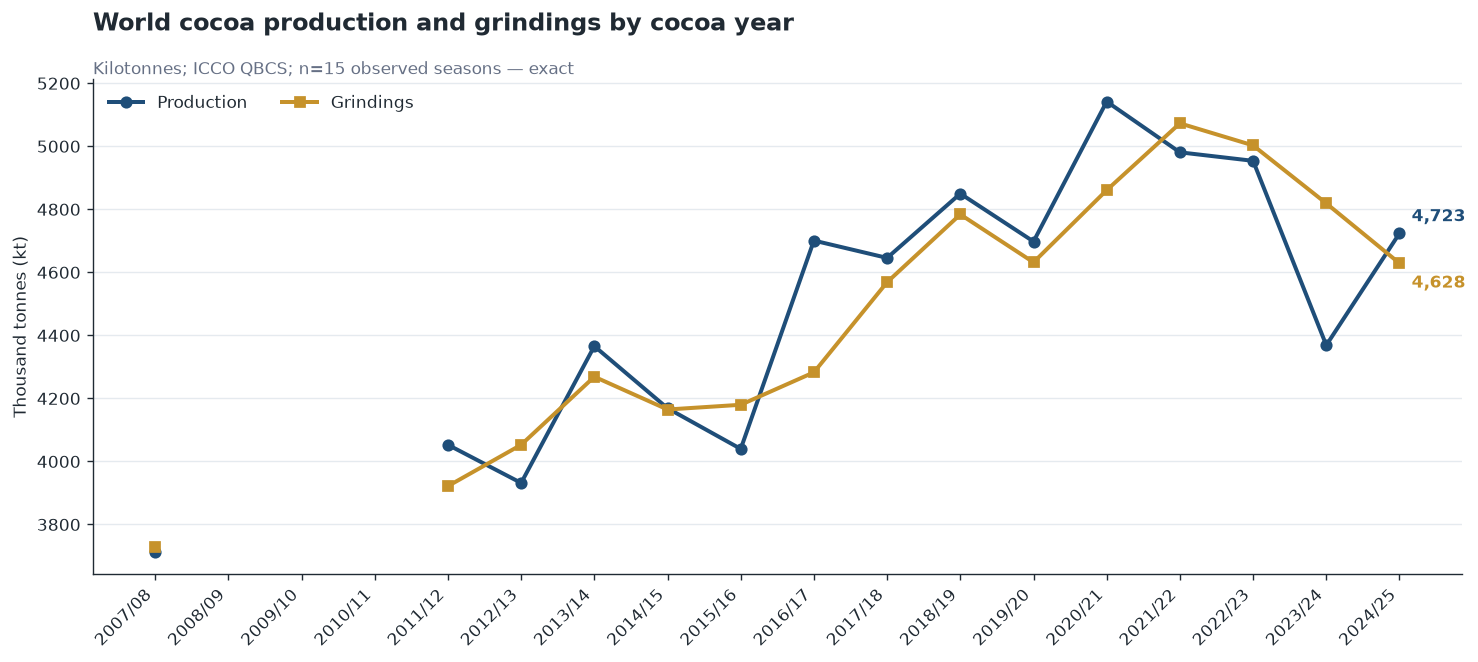

In [7]:
EXACTNESS="exact"
n=len(df)
years, labels, timeline = season_axis(analysis_df)
x = np.arange(len(years))

fig, ax = plt.subplots(figsize=(12, 5.4))
ax.plot(x, timeline["production_kt"], color=BLUE, marker="o", linewidth=2.3, label="Production")
ax.plot(x, timeline["grindings_kt"], color=GOLD, marker="s", linewidth=2.3, label="Grindings")
style_axis(ax)
ax.set_title("World cocoa production and grindings by cocoa year", loc="left", weight="bold", pad=28)
ax.text(0, 1.01, f"Kilotonnes; ICCO QBCS; n={n} observed seasons — {EXACTNESS}", transform=ax.transAxes, color=SLATE)
ax.set_ylabel("Thousand tonnes (kt)")
ax.set_xticks(x, labels, rotation=45, ha="right")
ax.legend(frameon=False, ncol=2, loc="upper left")
ax.annotate(f'{analysis_df.iloc[-1]["production_kt"]:,.0f}', (x[-1], analysis_df.iloc[-1]["production_kt"]), xytext=(7, 7), textcoords="offset points", color=BLUE, weight="bold")
ax.annotate(f'{analysis_df.iloc[-1]["grindings_kt"]:,.0f}', (x[-1], analysis_df.iloc[-1]["grindings_kt"]), xytext=(7, -14), textcoords="offset points", color=GOLD, weight="bold")
plt.tight_layout()
plt.show()

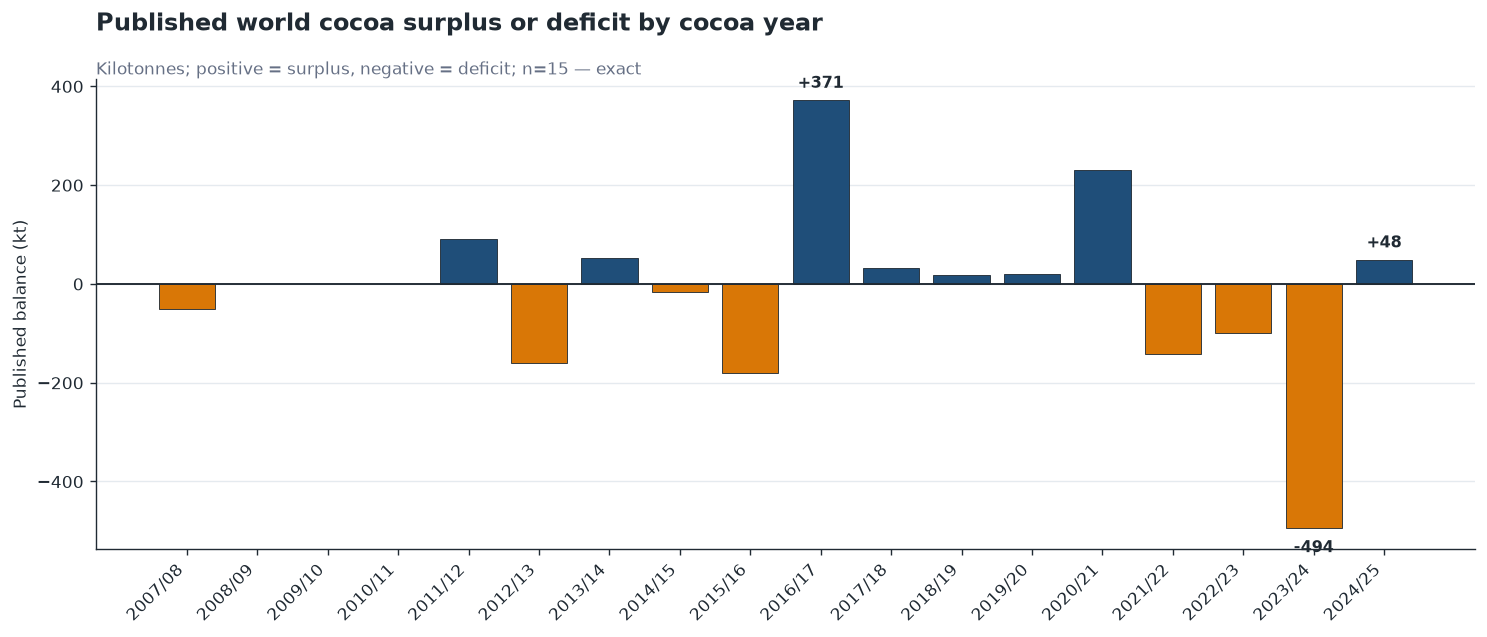

In [8]:
EXACTNESS="exact"
n=len(df)
years, labels, timeline = season_axis(analysis_df)
x = np.arange(len(years))
values = timeline["surplus_deficit_kt"]
colors = [BLUE if pd.notna(value) and value >= 0 else ORANGE for value in values]

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.bar(x, values, color=colors, edgecolor=INK, linewidth=0.5)
style_axis(ax)
ax.axhline(0, color=INK, linewidth=1.1)
ax.set_title("Published world cocoa surplus or deficit by cocoa year", loc="left", weight="bold", pad=28)
ax.text(0, 1.01, f"Kilotonnes; positive = surplus, negative = deficit; n={n} — {EXACTNESS}", transform=ax.transAxes, color=SLATE)
ax.set_ylabel("Published balance (kt)")
ax.set_xticks(x, labels, rotation=45, ha="right")
for idx, value in enumerate(values):
    if pd.notna(value) and (abs(value) >= 300 or idx == len(values) - 1):
        ax.text(idx, value + (18 if value >= 0 else -25), f"{value:+,.0f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=9, weight="bold")
plt.tight_layout()
plt.show()

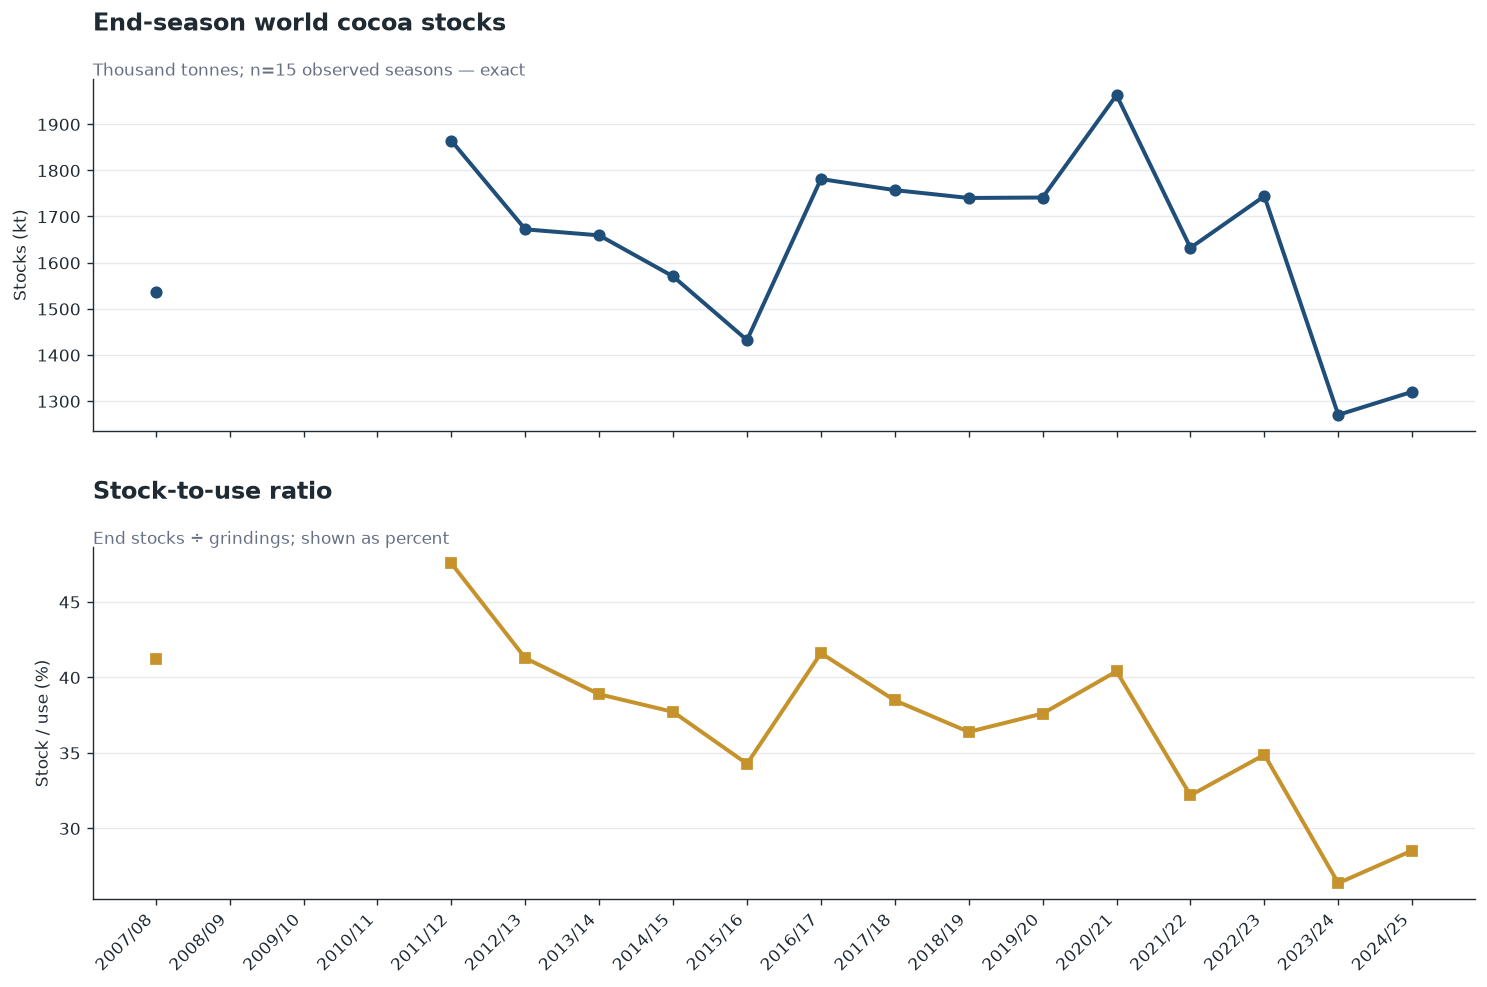

In [9]:
EXACTNESS="exact"
n=len(df)
years, labels, timeline = season_axis(analysis_df)
x = np.arange(len(years))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(x, timeline["end_stocks_kt"], color=BLUE, marker="o", linewidth=2.3)
style_axis(axes[0])
axes[0].set_title("End-season world cocoa stocks", loc="left", weight="bold", pad=28)
axes[0].text(0, 1.01, f"Thousand tonnes; n={n} observed seasons — {EXACTNESS}", transform=axes[0].transAxes, color=SLATE)
axes[0].set_ylabel("Stocks (kt)")

axes[1].plot(x, timeline["su_ratio"] * 100, color=GOLD, marker="s", linewidth=2.3)
style_axis(axes[1])
axes[1].set_title("Stock-to-use ratio", loc="left", weight="bold", pad=28)
axes[1].text(0, 1.01, "End stocks ÷ grindings; shown as percent", transform=axes[1].transAxes, color=SLATE)
axes[1].set_ylabel("Stock / use (%)")
axes[1].set_xticks(x, labels, rotation=45, ha="right")
plt.tight_layout(h_pad=2.5)
plt.show()

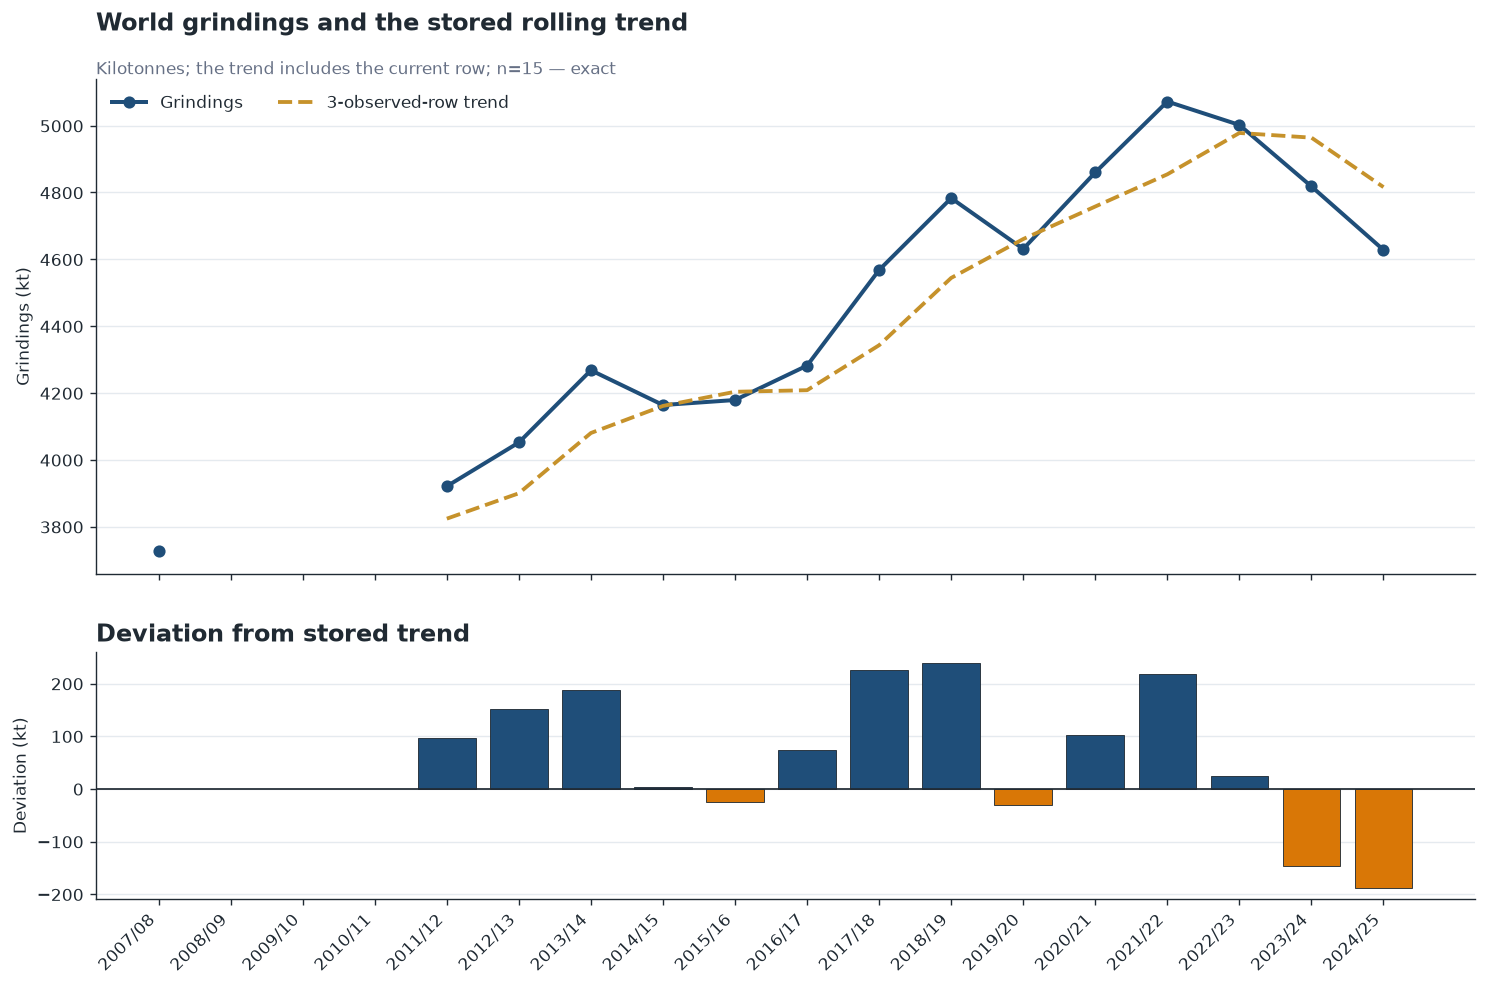

In [10]:
EXACTNESS="exact"
n=len(df)
years, labels, timeline = season_axis(analysis_df)
x = np.arange(len(years))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(x, timeline["grindings_kt"], color=BLUE, marker="o", linewidth=2.3, label="Grindings")
axes[0].plot(x, timeline["grindings_3yr_trend"], color=GOLD, linewidth=2.2, linestyle="--", label="3-observed-row trend")
style_axis(axes[0])
axes[0].set_title("World grindings and the stored rolling trend", loc="left", weight="bold", pad=28)
axes[0].text(0, 1.01, f"Kilotonnes; the trend includes the current row; n={n} — {EXACTNESS}", transform=axes[0].transAxes, color=SLATE)
axes[0].set_ylabel("Grindings (kt)")
axes[0].legend(frameon=False, ncol=2, loc="upper left")

deviation = timeline["grindings_trend_dev"]
colors = [BLUE if pd.notna(value) and value >= 0 else ORANGE for value in deviation]
axes[1].bar(x, deviation, color=colors, edgecolor=INK, linewidth=0.5)
style_axis(axes[1])
axes[1].axhline(0, color=INK, linewidth=1.0)
axes[1].set_title("Deviation from stored trend", loc="left", weight="bold")
axes[1].set_ylabel("Deviation (kt)")
axes[1].set_xticks(x, labels, rotation=45, ha="right")
plt.tight_layout(h_pad=2.5)
plt.show()

## What changed over time

- Across the uninterrupted `2011/12`–`2024/25` span, production increased at about **1.2% per year** and grindings at **1.3% per year**. These are descriptive CAGRs, not forecasts.
- The largest published surplus is **+371 kt in `2016/17`**; the largest deficit is **-494 kt in `2023/24`**. The sample contains **8 surplus** and **7 deficit** seasons.
- Stocks peaked at **1,963 kt in `2020/21`**, then reached **1,270 kt / 26.4% stock-to-use in `2023/24`**.
- The latest row improves from the stress year, but only modestly on inventory: stocks are **+50 kt** and stock/use **+2.2 percentage points** versus `2023/24`.

In [11]:
ranked = pd.concat([
    analysis_df.nsmallest(3, "surplus_deficit_kt").assign(exception="Largest deficits"),
    analysis_df.nlargest(3, "surplus_deficit_kt").assign(exception="Largest surpluses"),
    analysis_df.nsmallest(3, "su_ratio").assign(exception="Tightest stock/use"),
], ignore_index=True)
ranked = ranked[["exception", "cocoa_year", "surplus_deficit_kt", "end_stocks_kt", "su_ratio", "production_kt", "grindings_kt"]]
display(
    ranked.style.hide(axis="index").format({
        "surplus_deficit_kt": "{:+,.0f}", "end_stocks_kt": "{:,.0f}",
        "su_ratio": "{:.1%}", "production_kt": "{:,.0f}", "grindings_kt": "{:,.0f}",
    }).set_caption("Notable observed seasons — world totals, kt unless shown as percent")
)

exception,cocoa_year,surplus_deficit_kt,end_stocks_kt,su_ratio,production_kt,grindings_kt
Largest deficits,2023/24,-494,"1,270",26.4%,"4,368","4,818"
Largest deficits,2015/16,-180,"1,432",34.3%,"4,039","4,179"
Largest deficits,2012/13,-160,"1,672",41.3%,"3,931","4,052"
Largest surpluses,2016/17,+371,"1,781",41.6%,"4,700","4,282"
Largest surpluses,2020/21,+230,"1,963",40.4%,"5,141","4,860"
Largest surpluses,2011/12,+90,"1,864",47.5%,"4,052","3,921"
Tightest stock/use,2023/24,-494,"1,270",26.4%,"4,368","4,818"
Tightest stock/use,2024/25,+48,"1,320",28.5%,"4,723","4,628"
Tightest stock/use,2021/22,-142,"1,632",32.2%,"4,980","5,072"


## Within-source relationships

The most interpretable relationship here is whether published balance and inventory coverage move together. With only 15 observations, correlation is descriptive—not causal and not a target test.

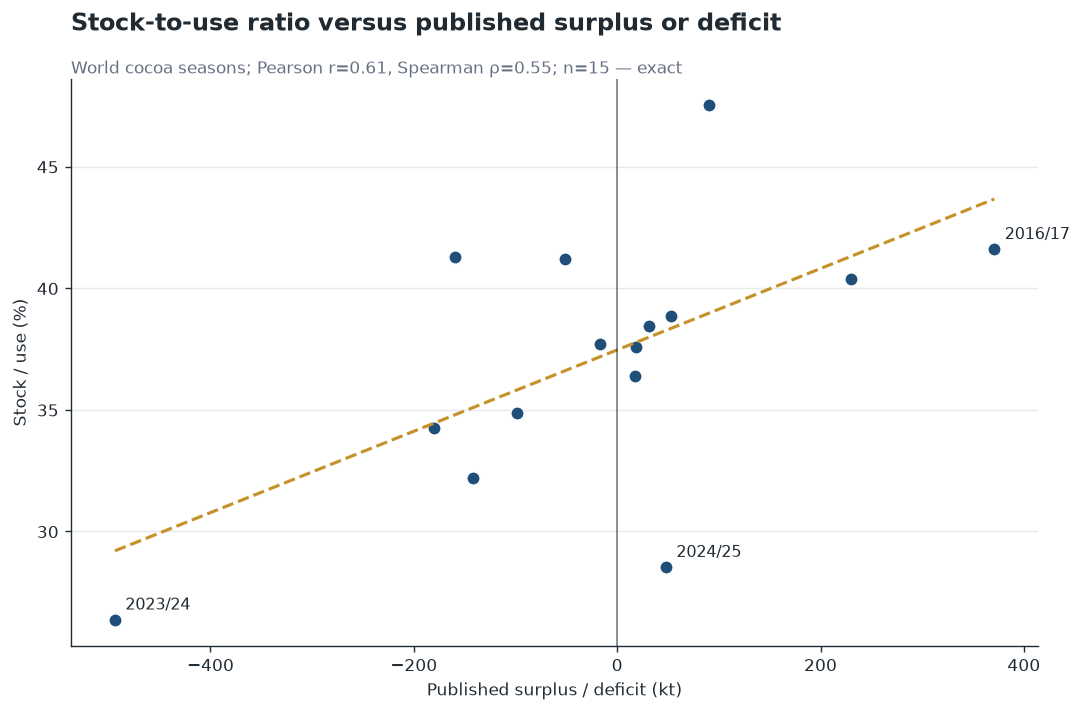

Pair,Pearson,Spearman,n
balance vs stock/use,0.61,0.55,15
production vs grindings,0.89,0.90,15
stocks vs stock/use,0.76,0.65,15


In [12]:
EXACTNESS="exact"
n=len(df)
x = analysis_df["surplus_deficit_kt"]
y = analysis_df["su_ratio"] * 100
pearson = x.corr(y)
spearman = x.corr(y, method="spearman")

fig, ax = plt.subplots(figsize=(8.8, 5.8))
ax.scatter(x, y, s=58, color=BLUE, edgecolor="white", linewidth=0.8)
fit = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, fit[0] * x_line + fit[1], color=GOLD, linestyle="--", linewidth=1.8)
for season in ["2016/17", "2023/24", "2024/25"]:
    row = analysis_df.loc[analysis_df["cocoa_year"] == season].iloc[0]
    ax.annotate(season, (row["surplus_deficit_kt"], row["su_ratio"] * 100), xytext=(6, 6), textcoords="offset points", fontsize=9)
style_axis(ax)
ax.axvline(0, color=INK, linewidth=0.9, alpha=0.65)
ax.set_title("Stock-to-use ratio versus published surplus or deficit", loc="left", weight="bold", pad=28)
ax.text(0, 1.01, f"World cocoa seasons; Pearson r={pearson:.2f}, Spearman ρ={spearman:.2f}; n={n} — {EXACTNESS}", transform=ax.transAxes, color=SLATE)
ax.set_xlabel("Published surplus / deficit (kt)")
ax.set_ylabel("Stock / use (%)")
plt.tight_layout()
plt.show()

correlations = pd.DataFrame({
    "Pair": ["balance vs stock/use", "production vs grindings", "stocks vs stock/use"],
    "Pearson": [
        analysis_df["surplus_deficit_kt"].corr(analysis_df["su_ratio"]),
        analysis_df["production_kt"].corr(analysis_df["grindings_kt"]),
        analysis_df["end_stocks_kt"].corr(analysis_df["su_ratio"]),
    ],
    "Spearman": [
        analysis_df["surplus_deficit_kt"].corr(analysis_df["su_ratio"], method="spearman"),
        analysis_df["production_kt"].corr(analysis_df["grindings_kt"], method="spearman"),
        analysis_df["end_stocks_kt"].corr(analysis_df["su_ratio"], method="spearman"),
    ],
    "n": [len(analysis_df)] * 3,
})
display(correlations.style.hide(axis="index").format({"Pearson": "{:.2f}", "Spearman": "{:.2f}"}))

### Relationship read

Published balance and stock/use have a **moderate positive association** in this small history (Pearson **0.61**, Spearman **0.55**, n=15). `2023/24` sits at the joint stress end, while `2016/17` is a high-surplus/high-coverage observation. This supports a market-tightness mechanism, but it does not prove predictive value.

## Timing and leakage: the one real blocker

- Silver keeps **latest current-vintage values**, not the historical bulletin sequence.
- Each metric independently uses its latest non-null current-vintage release, so one row can combine metrics from different releases. `latest_release_date` is only the row maximum.
- The registry does not declare a governed knowledge timestamp or publication lag, and later `prior` revisions are intentionally discarded.
- Therefore, same-season values and the unlagged trend fields are **not safe for preseason or historical-cutoff features**. A safe prototype must lag the source and confirm that the prior row's release was available by the cutoff.

### Joins are not the point here

This source is already a world aggregate with no geography or commodity column. It can join only on a governed cocoa-season mapping. Country-level or regional expansion would invent granularity the source does not contain.

## Feature-engineering opportunity—after the timing rule is fixed

The table is economically useful, but its candidates should be **lagged** and conditioned on release availability. Nothing below is promoted to production configuration.

| Candidate | Exact source-only transformation for target season *t* | Mechanism | Readiness |
|---|---|---|---|
| Prior stock/use | `su_ratio.shift(1)` | Inventory cushion / tightness | Conditional: prior release must predate cutoff |
| Prior published balance | `surplus_deficit_kt.shift(1)` | Supply-demand imbalance regime | Conditional: prior release must predate cutoff |
| Lagged production growth | `production_kt.pct_change().shift(1)` | Supply momentum | Conditional + gap-aware |
| Lagged grindings growth | `grindings_kt.pct_change().shift(1)` | Processing-demand momentum | Conditional + gap-aware |
| Lagged stock change | `end_stocks_kt.diff().shift(1)` | Inventory rebuilding / drawdown | Conditional + gap-aware |

**Do not derive:** same-season balance/stock/use for a pre-release target; unlagged `grindings_3yr_trend` or `grindings_trend_dev`; numeric encodings of `source`; or a reconstructed balance equal to production minus grindings.

In [13]:
prototype = analysis_df[["cocoa_year"]].copy()
prototype["prior_row_latest_release_date"] = analysis_df["latest_release_date"].shift(1)
prototype["prior_su_ratio"] = analysis_df["su_ratio"].shift(1)
prototype["prior_balance_kt"] = analysis_df["surplus_deficit_kt"].shift(1)
prototype["production_growth_lag1"] = analysis_df["production_kt"].pct_change().shift(1)
prototype["grindings_growth_lag1"] = analysis_df["grindings_kt"].pct_change().shift(1)
prototype["stock_change_lag1_kt"] = analysis_df["end_stocks_kt"].diff().shift(1)
display(
    prototype.tail(6).style.hide(axis="index").format({
        "prior_row_latest_release_date": lambda value: value.strftime("%Y-%m-%d"),
        "prior_su_ratio": "{:.1%}", "prior_balance_kt": "{:+,.0f}",
        "production_growth_lag1": "{:+.1%}", "grindings_growth_lag1": "{:+.1%}",
        "stock_change_lag1_kt": "{:+,.0f}",
    }, na_rep="—").set_caption(
        "Illustrative lagged values with the prior source row's release date — review only; not proof of PIT availability"
    )
)

cocoa_year,prior_row_latest_release_date,prior_su_ratio,prior_balance_kt,production_growth_lag1,grindings_growth_lag1,stock_change_lag1_kt
2019/20,2019-08-30,36.4%,+18,+4.4%,+4.7%,-17
2020/21,2020-12-02,37.6%,+19,-3.1%,-3.2%,+1
2021/22,2021-08-31,40.4%,+230,+9.5%,+4.9%,+222
2022/23,2023-05-31,32.2%,-142,-3.1%,+4.4%,-331
2023/24,2023-11-30,34.9%,-99,-0.5%,-1.4%,+112
2024/25,2025-05-30,26.4%,-494,-11.8%,-3.7%,-474


## Bottom line

1. **The data are understandable and analytically useful:** 15 clean world balance-sheet observations, complete core measures, and five coherent visual stories.
2. **The strongest historical signal is market tightness:** `2023/24` combines the sample's largest deficit, lowest stocks, and lowest stock/use. `2024/25` shows partial normalization, not a full inventory recovery.
3. **The source is not yet feature-ready for PIT backtests:** reconstruct or retain bulletin vintages and per-metric release dates first.
4. **Smallest next data repair:** preserve every bulletin release in a versioned release panel, add per-metric knowledge dates, and make the rolling trend calendar-aware. Then prototype the five lagged candidates above.

### Compact technical caveats

- QBCS source data are quarterly, while the Silver contract declares annual freshness.
- The physical trend is a three-**observed-row** window; the missing 2008/09–2010/11 block means the first computed trend spans more than three calendar seasons.
- `surplus_deficit_kt` is a published source metric, not an arithmetic identity of the two headline flows.
- The current pipeline's Raw→Bronze production wiring needs verification before relying on deterministic rebuilds.